In [1]:
from utils.plot_utils_v2 import *
from matplotlib.collections import LineCollection
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np

EXP_ID = 5  # Main run is exp 5, exp 4 also works as an additional test case
df = pd.read_csv('data/ghux_d7_coculture/ehux379_d7.csv')
df = df.loc[(df['exp'] == EXP_ID) & (df['d7_present'] == 1)]

# All units are in cells/mL
ehux_live_density = df['ehux'].values
ehux_live_time = df['time'].values
log_ehux_live_density = np.log(ehux_live_density + 1e-9)

ehux_dead_density = df['sytox+'].values
ehux_death_time = df['time'].values
log_ehux_dead_density = np.log(ehux_dead_density + 1e-9)

bacteria_density = df['bacteria'].values
bacteria_time = df['time'].values
log_bacteria_density = np.log(bacteria_density + 1e-9)

n1, n2, n3 = len(ehux_live_time), len(ehux_death_time), len(bacteria_time)


In [2]:
# Define ODEs for modulated and constant phi
def general_case(t, y, params):
    """Modulated pathogenicity: phi_B = rho * D."""
    P, D, B = y
    mu_P, k_P, delta_P, mu_B, k_B, beta_B, rho, lambda_D = params
    phi_B = rho * D

    dPdt = mu_P * P * (1 - P / k_P) - delta_P * P - phi_B * P * B
    dDdt = delta_P * P + phi_B * P * B - lambda_D * D
    dBdt = mu_B * B * (1 - B / k_B) + beta_B * phi_B * P * B
    return [dPdt, dDdt, dBdt]


def general_case_const(t, y, params):
    """Constant pathogenicity: phi_B = phi_const (fixed, not modulated by D)."""
    P, D, B = y
    mu_P, k_P, delta_P, mu_B, k_B, beta_B, phi_const, lambda_D = params
    phi_B = phi_const

    dPdt = mu_P * P * (1 - P / k_P) - delta_P * P - phi_B * P * B
    dDdt = delta_P * P + phi_B * P * B - lambda_D * D
    dBdt = mu_B * B * (1 - B / k_B) + beta_B * phi_B * P * B
    return [dPdt, dDdt, dBdt]


Here is where this case becomes unique. This ODE system is stiff. This happens when rates of change within a system vary drastically. This will cause the process to lock up if you don't use a proper sampler / solver. Here is how we chose to solve the issue. 

We are still going to use PyMC, however, instead of using the integrated solver we will use an external SciPy ODE solver to get around the stiffness issue. We declare a custom operator (**Op**) with one input vector (**itypes**) and one output matrix (**otypes**). It will be initialized with your observed times. **perform** is the default call for the runtime computation of the **Op**. See in Cell 5 how the parameters and inital values are passed to the **Op**. The first 4 are the parameters and last 3 are the initial conditions (**theta** and **y0**).

The solve_ivp call should follow this form. The inputs to the function are as follows:

**fun**: The ODE function(s)  
**t_span**: first and last time  
**y0**: Initial Values  
**t_eval**: exact time points the ODE will be evaluated at  
**method**: This is up to the user but for our case we chose LSODA. It auto-detects stiffness and switches between Adams (non-stiff) and BDF (stiff) methods.

Lastly, the output is transposed to match the form PyMC expects. 

In [3]:
import pytensor.tensor as pt
from pytensor.graph.op import Op
from scipy.integrate import solve_ivp


class SolveIVPWrapper(Op):
    itypes = [pt.dvector]
    otypes = [pt.dvector]

    def __init__(self, ode_func, t_obs_list, n_params=8, rtol=1e-6, atol=1e-8, penalty=1e8):
        self.ode_func = ode_func
        self.t_obs_list = [np.asarray(t, dtype=float) for t in t_obs_list]
        self.n_params = n_params
        self.rtol = rtol
        self.atol = atol
        self.penalty = penalty

        self.t_grid = np.unique(np.concatenate(self.t_obs_list))
        self.t_span = (self.t_grid.min(), self.t_grid.max())
        self._total_len = sum(len(t) for t in self.t_obs_list)

    def _solve(self, params, y0, method):
        try:
            return solve_ivp(
                self.ode_func, self.t_span, y0,
                t_eval=self.t_grid, method=method, args=(params,),
                rtol=self.rtol, atol=self.atol,
            )
        except Exception:
            return None

    def perform(self, node, inputs, outputs):
        (theta_y0,) = inputs
        params = theta_y0[: self.n_params]
        y0 = theta_y0[self.n_params:]

        sol = self._solve(params, y0, "LSODA")
        if sol is None or not sol.success or not np.all(np.isfinite(sol.y)):
            sol = self._solve(params, y0, "BDF")

        if sol is None or not sol.success or not np.all(np.isfinite(sol.y)):
            outputs[0][0] = np.full(self._total_len, self.penalty)
            return

        preds = [np.interp(t, self.t_grid, sol.y[i]) for i, t in enumerate(self.t_obs_list)]
        outputs[0][0] = np.concatenate(preds)


ode_op_mod = SolveIVPWrapper(general_case, t_obs_list=[ehux_live_time, ehux_death_time, bacteria_time])
ode_op_const = SolveIVPWrapper(general_case_const, t_obs_list=[ehux_live_time, ehux_death_time, bacteria_time])


This is where we create the MCMC 'loop': Sample Priors -> Estimate ODE @ times -> check fit

First, proirs. You have all kinds of options. Uniform, normal, lognormal, halfnormal. It all depends on what you need. For our parameters we choose uniform priors. These uniform priors say, "we believe the proper value for the model will be equally likely within this range and WILL NOT be outside of it". For our initial conditions we choose a lognormal distribution. This says, "we believe our value is around some **x** given a normalesque strictly positive distribution". For our sigma terms (error), we choose a halfnormal distribution. This is usually used for your error or standard deviation since neither can be negative and you can tune how quickly it tails off. Below are the priors visualized. 

<img src="../../figures/priors_c3.png" width="450"/>

After the priors are declared the next function call will be for the solution of the model given its current estimates. Pay attention to the order in which you pass your priors!

The final functions are the likelihood estimations of the model's states. This is where the model tests how well it estimated the observed data. We pass it our log transformed estimated data, the sigma values from the iteration's sample, and log transformed observed data. Now just let PyMC simply work its magic!

In [4]:
## Cell 5 -- Model A: modulated pathogenicity (phi_B = rho * D) ##
SIGMA_FIXED = 0.3 * np.log(10)

import pymc as pm

with pm.Model() as model_mod:
    mu_P     = pm.LogNormal("mu_P",     mu=np.log(4.4668e-01), sigma=0.4)
    k_P      = pm.LogNormal("k_P",      mu=np.log(4.3652e+06), sigma=0.4)
    delta_P  = pm.LogNormal("delta_P",  mu=np.log(7.4131e-02), sigma=0.4)
    mu_B     = pm.LogNormal("mu_B",     mu=np.log(4.8978e-01), sigma=0.4)
    k_B      = pm.LogNormal("k_B",      mu=np.log(4.3652e+07), sigma=0.4)
    beta_B   = pm.LogNormal("beta_B",   mu=np.log(4.0500e+00), sigma=0.4)
    rho      = pm.LogNormal("rho",      mu=np.log(2.1878e-14),  sigma=0.4)
    lambda_D = pm.LogNormal("lambda_D", mu=np.log(4.8978e-01), sigma=0.4)

    P0 = pm.LogNormal("P0", mu=np.log(1.2303e+05), sigma=0.4)
    D0 = pm.LogNormal("D0", mu=np.log(1.9226e+04), sigma=0.4)
    B0 = pm.LogNormal("B0", mu=np.log(1.3804e+05), sigma=0.4)

    theta_y0 = pt.stack([mu_P, k_P, delta_P, mu_B, k_B, beta_B, rho, lambda_D, P0, D0, B0])
    preds = ode_op_mod(theta_y0)

    live     = preds[:n1]
    dead     = preds[n1:n1 + n2]
    bacteria = preds[n1 + n2:]

    pm.Normal("Y_live", mu=pm.math.log(live + 1e-9), sigma=SIGMA_FIXED, observed=log_ehux_live_density)
    pm.Normal("Y_dead", mu=pm.math.log(dead + 1e-9), sigma=SIGMA_FIXED, observed=log_ehux_dead_density)
    pm.Normal("Y_bacteria", mu=pm.math.log(bacteria + 1e-9), sigma=SIGMA_FIXED, observed=log_bacteria_density)


In [5]:
PHI_CONST_CENTER = 1.9498e-08  # carried over from bacteria_ehux_experiment.py's PRIORS_CONST

with pm.Model() as model_const:
    mu_P     = pm.LogNormal("mu_P",     mu=np.log(4.4668e-01), sigma=0.4)
    k_P      = pm.LogNormal("k_P",      mu=np.log(4.3652e+06), sigma=0.4)
    delta_P  = pm.LogNormal("delta_P",  mu=np.log(7.4131e-02), sigma=0.4)
    mu_B     = pm.LogNormal("mu_B",     mu=np.log(4.8978e-01), sigma=0.4)
    k_B      = pm.LogNormal("k_B",      mu=np.log(4.3652e+07), sigma=0.4)
    beta_B   = pm.LogNormal("beta_B",   mu=np.log(4.0500e+00), sigma=0.4)
    phi_const = pm.LogNormal("phi_const", mu=np.log(PHI_CONST_CENTER), sigma=0.4)
    lambda_D = pm.LogNormal("lambda_D", mu=np.log(4.8978e-01), sigma=0.4)

    P0 = pm.LogNormal("P0", mu=np.log(1.2303e+05), sigma=0.4)
    D0 = pm.LogNormal("D0", mu=np.log(1.9226e+04), sigma=0.4)
    B0 = pm.LogNormal("B0", mu=np.log(1.3804e+05), sigma=0.4)

    theta_y0 = pt.stack([mu_P, k_P, delta_P, mu_B, k_B, beta_B, phi_const, lambda_D, P0, D0, B0])
    preds = ode_op_const(theta_y0)

    live     = preds[:n1]
    dead     = preds[n1:n1 + n2]
    bacteria = preds[n1 + n2:]

    pm.Normal("Y_live", mu=pm.math.log(live + 1e-9), sigma=SIGMA_FIXED, observed=log_ehux_live_density)
    pm.Normal("Y_dead", mu=pm.math.log(dead + 1e-9), sigma=SIGMA_FIXED, observed=log_ehux_dead_density)
    pm.Normal("Y_bacteria", mu=pm.math.log(bacteria + 1e-9), sigma=SIGMA_FIXED, observed=log_bacteria_density)


This is how you call and run the model!

**draws**: poterior values to be generated.  
**tune**: Some under the hood PyMC magic that 'warms it up'. Keep this between 500 and 2000 depending on how complex your model is.  
**chains / cores**: Amount of chains you want to compute in parallel. Keep these values the same for most basic usage. PyMC recommends you run at least 4 chains.    
**step**: By default PyMC uses NUTS (No U-Turn Sampler). If you want to use something other than NUTS this is where you declare it.  
**return_inferencedata**: returns an ARVIZ inferencedata object which we'll use for easy reading of our output.  

In [6]:
with model_mod:
    trace_mod = pm.sample(step=pm.DEMetropolisZ(), draws=30000, tune=15000, chains=4, cores=4,
                      return_inferencedata=True)

with model_const:
    trace_const = pm.sample(step=pm.DEMetropolisZ(), draws=30000, tune=15000, chains=4, cores=4,
                      return_inferencedata=True)

Multiprocess sampling (4 chains in 4 jobs)
DEMetropolisZ: [mu_P, k_P, delta_P, mu_B, k_B, beta_B, rho, lambda_D, P0, D0, B0]


Output()

Sampling 4 chains for 15_000 tune and 30_000 draw iterations (60_000 + 120_000 draws total) took 95 seconds.
Multiprocess sampling (4 chains in 4 jobs)
DEMetropolisZ: [mu_P, k_P, delta_P, mu_B, k_B, beta_B, phi_const, lambda_D, P0, D0, B0]


Output()

Sampling 4 chains for 15_000 tune and 30_000 draw iterations (60_000 + 120_000 draws total) took 84 seconds.


To interpret the output we have some user-defined postprocessing and plotting functions. They are in our GitHub repo.

Sampling: [B0, D0, P0, Y_bacteria, Y_dead, Y_live, beta_B, delta_P, k_B, k_P, lambda_D, mu_B, mu_P, rho]


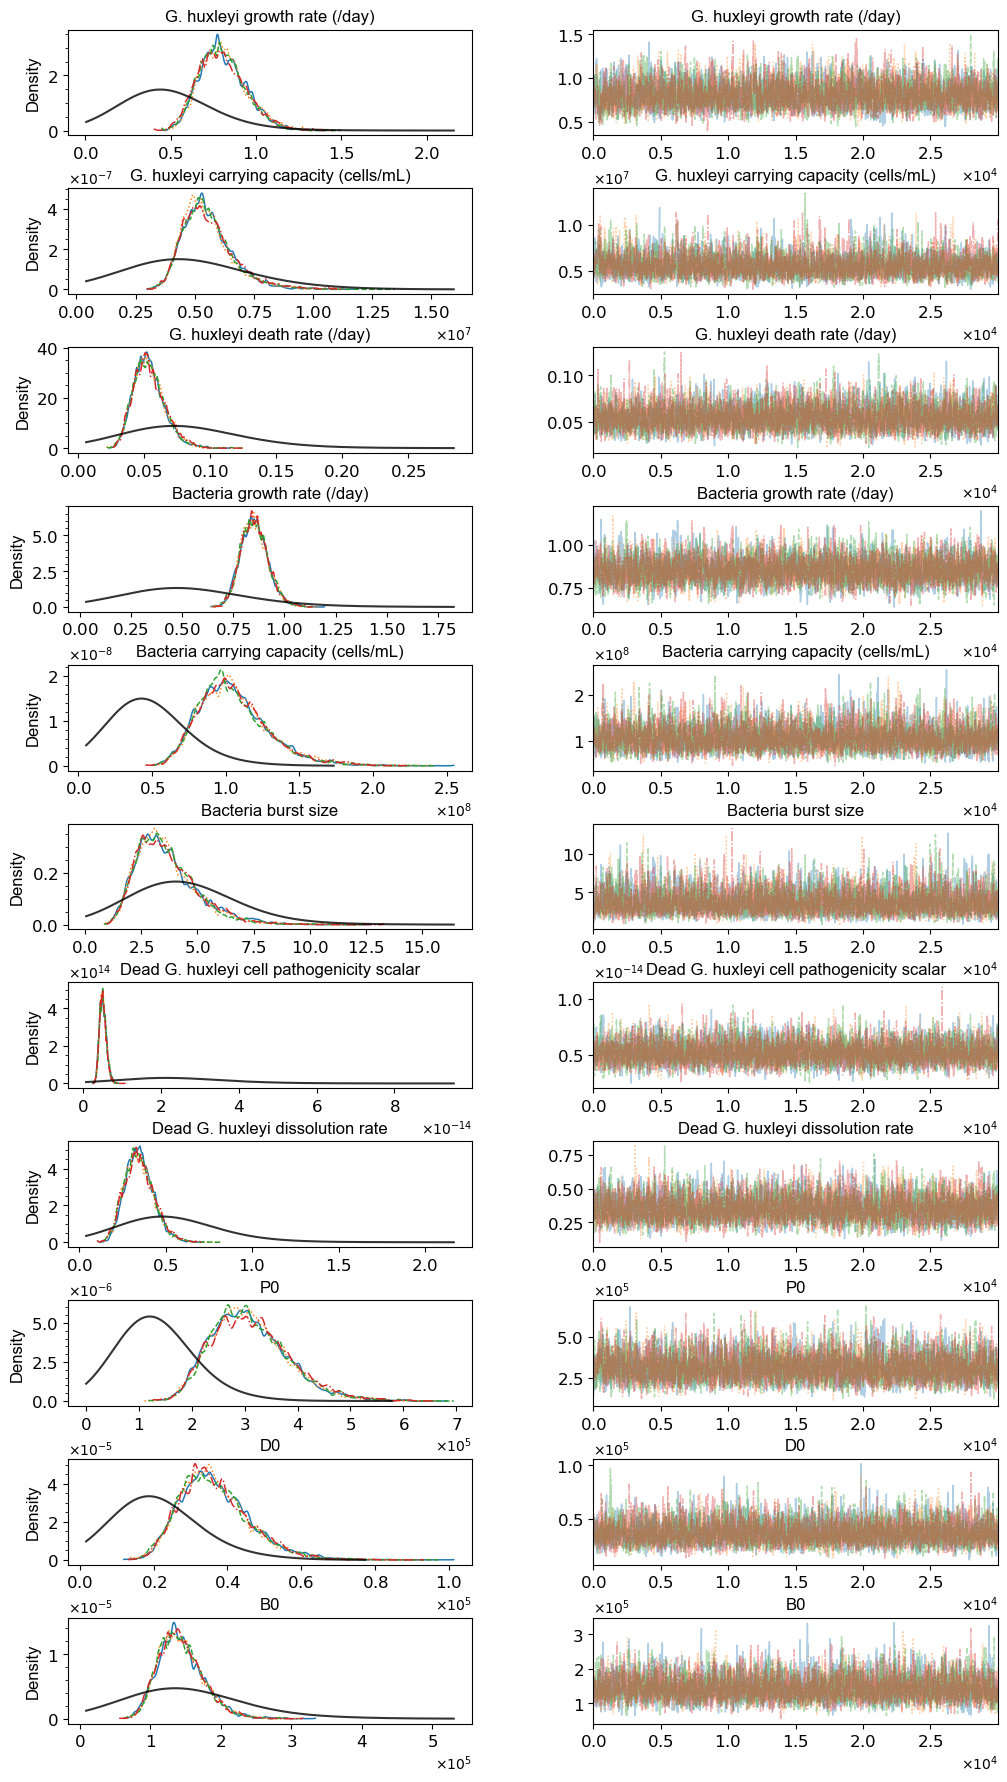

Sampling: [B0, D0, P0, Y_bacteria, Y_dead, Y_live, beta_B, delta_P, k_B, k_P, lambda_D, mu_B, mu_P, phi_const]


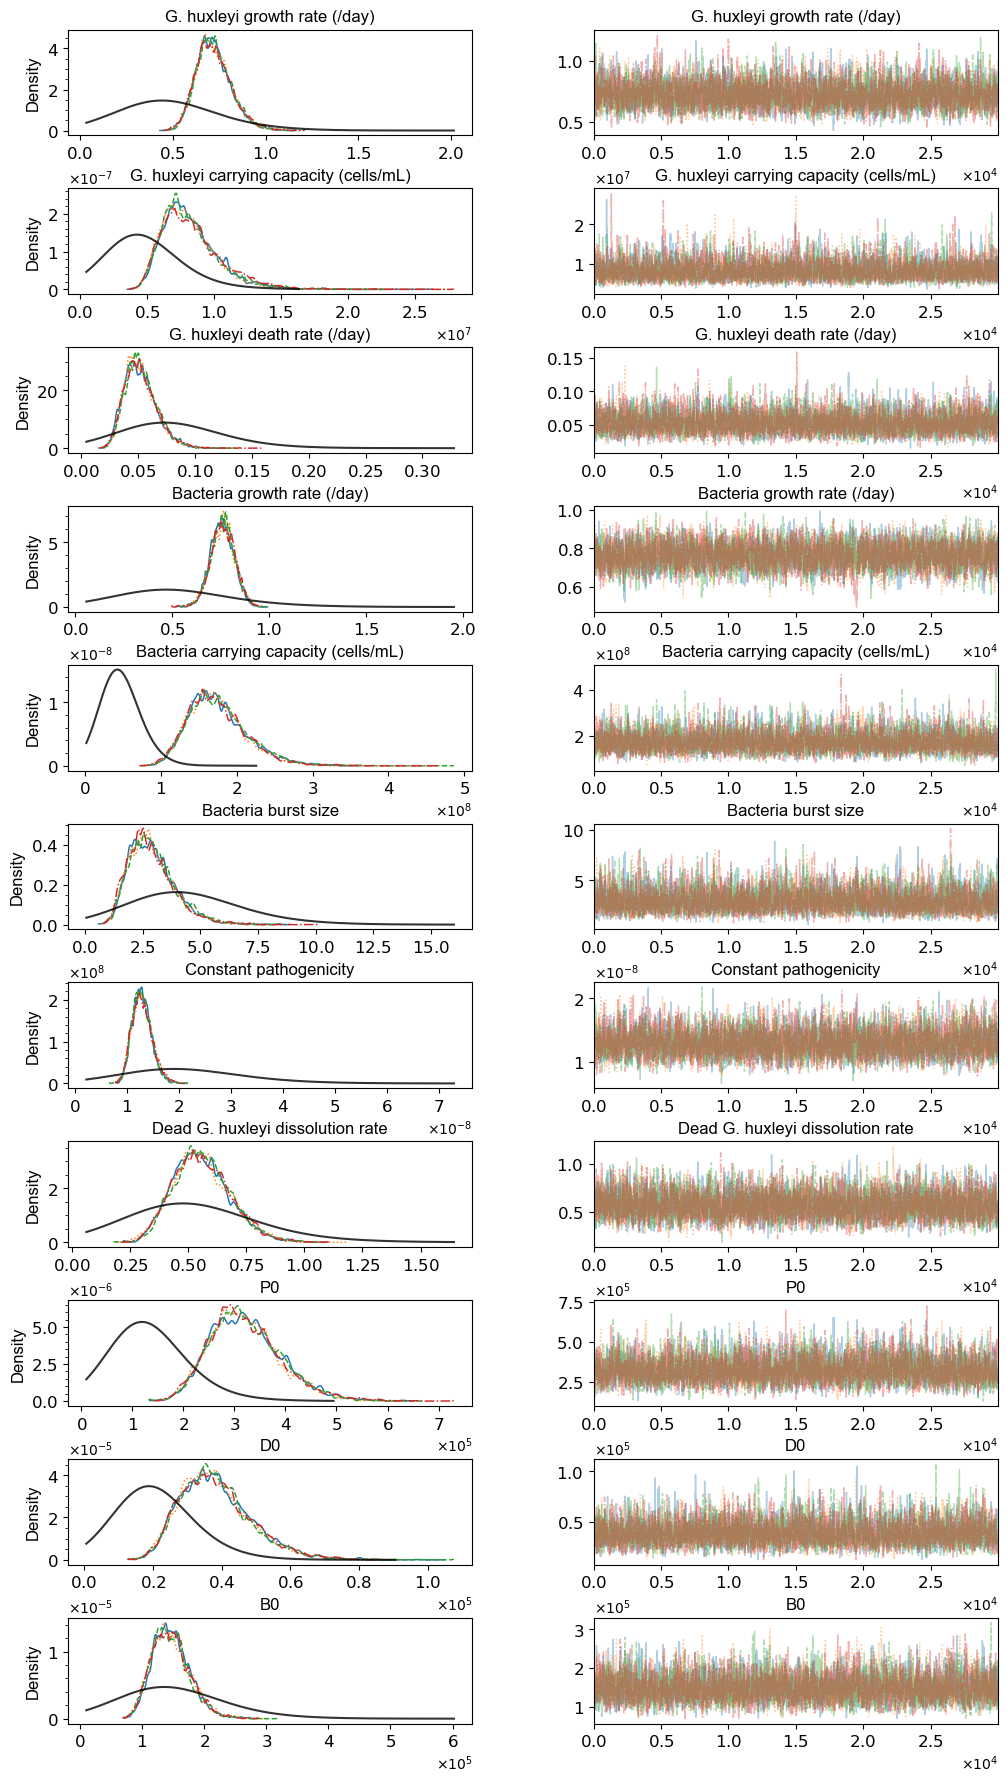

array([[<Axes: title={'center': 'G. huxleyi growth rate (/day)'}, ylabel='Density'>,
        <Axes: title={'center': 'G. huxleyi growth rate (/day)'}>],
       [<Axes: title={'center': 'G. huxleyi carrying capacity (cells/mL)'}, ylabel='Density'>,
        <Axes: title={'center': 'G. huxleyi carrying capacity (cells/mL)'}>],
       [<Axes: title={'center': 'G. huxleyi death rate (/day)'}, ylabel='Density'>,
        <Axes: title={'center': 'G. huxleyi death rate (/day)'}>],
       [<Axes: title={'center': 'Bacteria growth rate (/day)'}, ylabel='Density'>,
        <Axes: title={'center': 'Bacteria growth rate (/day)'}>],
       [<Axes: title={'center': 'Bacteria carrying capacity (cells/mL)'}, ylabel='Density'>,
        <Axes: title={'center': 'Bacteria carrying capacity (cells/mL)'}>],
       [<Axes: title={'center': 'Bacteria burst size'}, ylabel='Density'>,
        <Axes: title={'center': 'Bacteria burst size'}>],
       [<Axes: title={'center': 'Constant pathogenicity'}, ylabel='Densi

In [8]:
plot_trace(trace=trace_mod, model=model_mod,
           fontname='Arial', fontsize=12, num_prior_samples=2000,
           var_names_map={'mu_P': 'G. huxleyi growth rate (/day)', 'k_P': 'G. huxleyi carrying capacity (cells/mL)',
                          'delta_P': 'G. huxleyi death rate (/day)', 'mu_B': 'Bacteria growth rate (/day)',
                          'k_B': 'Bacteria carrying capacity (cells/mL)', 'beta_B': 'Bacteria burst size',
                          'rho': 'Dead G. huxleyi cell pathogenicity scalar', 'lambda_D': 'Dead G. huxleyi dissolution rate'},
           var_order=['mu_P', 'k_P', 'delta_P', 'mu_B', 'k_B', 'beta_B', 'rho', 'lambda_D', 'P0', 'D0', 'B0'],
           save_path='figures/MCMC_ghux_general_chains_mod.png')

plot_trace(trace=trace_const, model=model_const,
           fontname='Arial', fontsize=12, num_prior_samples=2000,
           var_names_map={'mu_P': 'G. huxleyi growth rate (/day)', 'k_P': 'G. huxleyi carrying capacity (cells/mL)',
                          'delta_P': 'G. huxleyi death rate (/day)', 'mu_B': 'Bacteria growth rate (/day)',
                          'k_B': 'Bacteria carrying capacity (cells/mL)', 'beta_B': 'Bacteria burst size',
                          'phi_const': 'Constant pathogenicity', 'lambda_D': 'Dead G. huxleyi dissolution rate'},
           var_order=['mu_P', 'k_P', 'delta_P', 'mu_B', 'k_B', 'beta_B', 'phi_const', 'lambda_D', 'P0', 'D0', 'B0'],
           save_path='figures/MCMC_ghux_general_chains_const.png')

In [9]:
def posterior_predictive_bands(trace, param_names, ode_func, t_dense, n_samples=300, seed=42):
    post = trace.posterior.stack(draws=("chain", "draw"))
    n_avail = post.sizes["draws"]
    rng = np.random.default_rng(seed)
    idx = rng.choice(n_avail, size=min(n_samples, n_avail), replace=False)

    all_names = param_names + ["P0", "D0", "B0"]
    flat = {name: np.asarray(post[name].values).reshape(-1) for name in all_names}

    P_curves, D_curves, B_curves = [], [], []
    t_span = (float(t_dense.min()), float(t_dense.max()))

    for i in idx:
        params = [flat[name][i] for name in param_names]
        y0 = [flat["P0"][i], flat["D0"][i], flat["B0"][i]]
        sol = None
        for method in ("LSODA", "BDF"):
            try:
                sol = solve_ivp(ode_func, t_span, y0, t_eval=t_dense, method=method,
                                 args=(params,), rtol=1e-6, atol=1e-8)
                if sol.success and np.all(np.isfinite(sol.y)):
                    break
            except Exception:
                sol = None
        if sol is None or not sol.success or not np.all(np.isfinite(sol.y)):
            continue
        P_curves.append(sol.y[0]); D_curves.append(sol.y[1]); B_curves.append(sol.y[2])

    if len(P_curves) == 0:
        raise RuntimeError("All posterior-predictive solves failed.")

    bands = {}
    for key, curves in (("P", P_curves), ("D", D_curves), ("B", B_curves)):
        arr = np.array(curves)
        bands[key + "_lo"]  = np.percentile(arr, 2.5, axis=0)
        bands[key + "_med"] = np.percentile(arr, 50, axis=0)
        bands[key + "_hi"]  = np.percentile(arr, 97.5, axis=0)
    return bands


t_max = max(ehux_live_time.max(), ehux_death_time.max(), bacteria_time.max())
t_dense = np.linspace(0, t_max, 300)

PARAM_ORDER_MOD   = ['mu_P', 'k_P', 'delta_P', 'mu_B', 'k_B', 'beta_B', 'rho', 'lambda_D']
PARAM_ORDER_CONST = ['mu_P', 'k_P', 'delta_P', 'mu_B', 'k_B', 'beta_B', 'phi_const', 'lambda_D']

bands_mod   = posterior_predictive_bands(trace_mod,   PARAM_ORDER_MOD,   general_case,       t_dense)
bands_const = posterior_predictive_bands(trace_const, PARAM_ORDER_CONST, general_case_const, t_dense)


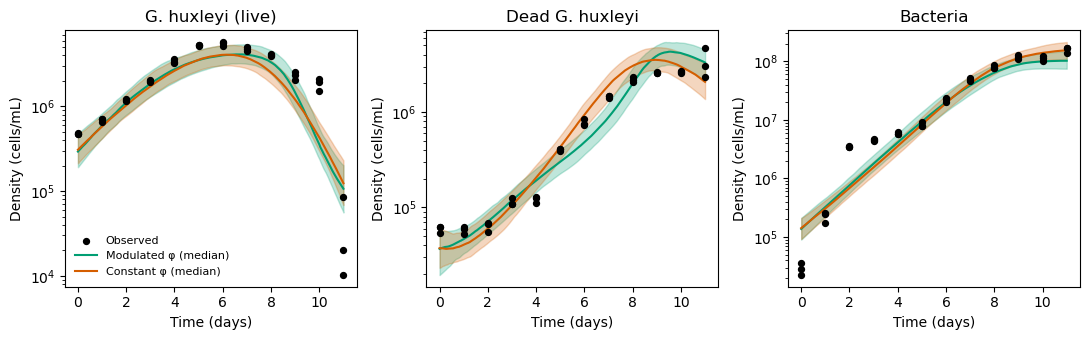

Modulated φ  -- mean: -108.28   median: -107.94   SD: 3.28
Constant φ   -- mean: -109.56   median: -109.15   SD: 3.57
Delta median (mod - const): 1.21


/var/folders/mp/cspgvq_d2h13_l03bp7hsr0r0000gn/T/ipykernel_64248/534277547.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=ll_df, x='Model', y='Log-likelihood', palette=[COLOR_MOD, COLOR_CONST], inner='box', ax=ax)


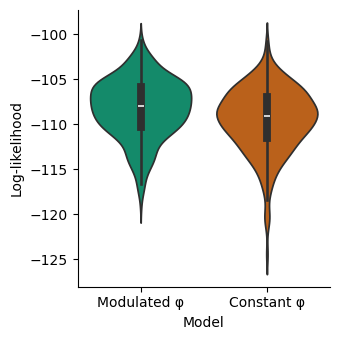

In [10]:
# comparing modulated vs constant pathogenicity

COLOR_MOD   = '#009E73'
COLOR_CONST = '#D55E00'
COLOR_OBS   = '#000000'

fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
labels = ['G. huxleyi (live)', 'Dead G. huxleyi', 'Bacteria']
obs_data = [(ehux_live_time, ehux_live_density, 'P'),
            (ehux_death_time, ehux_dead_density, 'D'),
            (bacteria_time, bacteria_density, 'B')]

for ax, label, (t_obs, y_obs, key) in zip(axes, labels, obs_data):
    ax.scatter(t_obs, y_obs, color=COLOR_OBS, s=18, zorder=5, label='Observed')

    ax.plot(t_dense, bands_mod[key + '_med'], color=COLOR_MOD, label='Modulated φ (median)')
    ax.fill_between(t_dense, bands_mod[key + '_lo'], bands_mod[key + '_hi'], color=COLOR_MOD, alpha=0.25)

    ax.plot(t_dense, bands_const[key + '_med'], color=COLOR_CONST, label='Constant φ (median)')
    ax.fill_between(t_dense, bands_const[key + '_lo'], bands_const[key + '_hi'], color=COLOR_CONST, alpha=0.25)

    ax.set_title(label)
    ax.set_xlabel('Time (days)')
    ax.set_ylabel('Density (cells/mL)')
    ax.set_yscale('log')

axes[0].legend(frameon=False, fontsize=8, loc='lower left')
plt.tight_layout()
# plt.savefig('figures/mod_vs_const_bands.png', dpi=300, bbox_inches='tight')
plt.show()

def total_loglik(params, y0, ode_func, sigma=SIGMA_FIXED):
    t_grid = ode_op_mod.t_grid  # identical grid for both Ops (same t_obs_list)
    sol = None
    for method in ("LSODA", "BDF"):
        try:
            sol = solve_ivp(ode_func, (t_grid.min(), t_grid.max()), y0, t_eval=t_grid,
                             method=method, args=(params,), rtol=1e-6, atol=1e-8)
            if sol.success and np.all(np.isfinite(sol.y)):
                break
        except Exception:
            sol = None
    if sol is None or not sol.success or not np.all(np.isfinite(sol.y)):
        return -1e10

    live_pred     = np.interp(ehux_live_time, t_grid, sol.y[0])
    dead_pred     = np.interp(ehux_death_time, t_grid, sol.y[1])
    bacteria_pred = np.interp(bacteria_time, t_grid, sol.y[2])

    ll = 0.0
    for pred, log_obs in [(live_pred, log_ehux_live_density),
                          (dead_pred, log_ehux_dead_density),
                          (bacteria_pred, log_bacteria_density)]:
        r = np.log(pred + 1e-9) - log_obs
        ll += -0.5 * np.sum((r / sigma) ** 2 + np.log(2 * np.pi * sigma ** 2))
    return float(ll)


def loglik_samples(trace, param_names, ode_func, n_samples=500, seed=42):
    post = trace.posterior.stack(draws=("chain", "draw"))
    n_avail = post.sizes["draws"]
    rng = np.random.default_rng(seed)
    idx = rng.choice(n_avail, size=min(n_samples, n_avail), replace=False)
    all_names = param_names + ["P0", "D0", "B0"]
    flat = {name: np.asarray(post[name].values).reshape(-1) for name in all_names}

    lls = []
    for i in idx:
        params = [flat[name][i] for name in param_names]
        y0 = [flat["P0"][i], flat["D0"][i], flat["B0"][i]]
        lls.append(total_loglik(params, y0, ode_func))
    return np.array(lls)


ll_mod   = loglik_samples(trace_mod,   PARAM_ORDER_MOD,   general_case)
ll_const = loglik_samples(trace_const, PARAM_ORDER_CONST, general_case_const)

print('Modulated φ  -- mean: %.2f   median: %.2f   SD: %.2f' % (ll_mod.mean(), np.median(ll_mod), ll_mod.std()))
print('Constant φ   -- mean: %.2f   median: %.2f   SD: %.2f' % (ll_const.mean(), np.median(ll_const), ll_const.std()))
print('Delta median (mod - const): %.2f' % (np.median(ll_mod) - np.median(ll_const)))

import seaborn as sns
ll_df = pd.DataFrame({
    'Log-likelihood': np.concatenate([ll_mod, ll_const]),
    'Model': (['Modulated φ'] * len(ll_mod) + ['Constant φ'] * len(ll_const)),
})
fig, ax = plt.subplots(figsize=(3.5, 3.5))
sns.violinplot(data=ll_df, x='Model', y='Log-likelihood', palette=[COLOR_MOD, COLOR_CONST], inner='box', ax=ax)
sns.despine()
plt.tight_layout()
# plt.savefig('figures/mod_vs_const_loglik.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
## Export Posteriors
# import json

# def extract_medians(trace, param_names):
#     post = trace.posterior
#     all_names = param_names + ["P0", "D0", "B0"]
#     return {name: float(post[name].median()) for name in all_names}

# params_mod_optimal   = extract_medians(trace_mod,   PARAM_ORDER_MOD)
# params_const_optimal = extract_medians(trace_const, PARAM_ORDER_CONST)

# print('\nOptimal parameters (posterior median) -- Modulated φ')
# for k, v in params_mod_optimal.items():
#     print(f'  {k:12s} {v:.6e}')

# print('\nOptimal parameters (posterior median) -- Constant φ')
# for k, v in params_const_optimal.items():
#     print(f'  {k:12s} {v:.6e}')

# with open('data/optimal_params_mod.json', 'w') as f:
#     json.dump(params_mod_optimal, f, indent=2)

# with open('data/optimal_params_const.json', 'w') as f:
#     json.dump(params_const_optimal, f, indent=2)

# print('\nSaved to data/optimal_params_mod.json and data/optimal_params_const.json')
